### **Nigar Rustamova**

## Assessment | Full ML Pipeline: From Clustering to Deployment

## Task 1 — Unsupervised Exploration

In [1]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV, learning_curve
from sklearn.metrics import f1_score, precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc, roc_auc_score
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder, label_binarize
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import classification_report
import joblib
import json

import warnings
warnings.filterwarnings('ignore')

In [2]:
# Load the Palmer Penguins dataset
df = sns.load_dataset("penguins")

In [3]:
df.shape

(344, 7)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    str    
 1   island             344 non-null    str    
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    str    
dtypes: float64(4), str(3)
memory usage: 24.9 KB


In [5]:
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


In [6]:
df.isna().sum()

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

In [7]:
df[df.isna().any(axis=1)]

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
8,Adelie,Torgersen,34.1,18.1,193.0,3475.0,NaN
9,Adelie,Torgersen,42.0,20.2,190.0,4250.0,NaN
10,Adelie,Torgersen,37.8,17.1,186.0,3300.0,NaN
11,Adelie,Torgersen,37.8,17.3,180.0,3700.0,NaN
47,Adelie,Dream,37.5,18.9,179.0,2975.0,NaN
246,Gentoo,Biscoe,44.5,14.3,216.0,4100.0,NaN
286,Gentoo,Biscoe,46.2,14.4,214.0,4650.0,NaN
324,Gentoo,Biscoe,47.3,13.8,216.0,4725.0,NaN
336,Gentoo,Biscoe,44.5,15.7,217.0,4875.0,NaN


In [8]:
df = df.dropna()

## Data Cleaning: Handling Missing Values

Before proceeding with the exploratory analysis and model training, we must address the missing values in the dataset.

### Observations:
* **Missing Features:** A small number of rows contain `NaN` values for physical measurements (bill length, bill depth, flipper length, and body mass).
* **Missing Target/Labels:** Some rows are missing the `sex` attribute (11 rows).

### Decision: Listwise Deletion (Dropping Rows)
I have chosen to drop the rows containing missing values using `df.dropna()` for the following reasons:
1. **Instructional Requirement:** Task 2 of this assessment explicitly requires dropping rows with missing values.
2. **Data Integrity:** Since the missing values in the physical measurements represent our primary features for clustering (Task 1), imputing them could introduce artificial bias.
3. **Low Impact:** The 11 missing rows represent less than 4% of the total dataset (344 total observations). Removing them maintains a sufficiently large sample size for robust training without compromising the quality of the data.

After dropping, the dataset size is reduced from 344 to 333 observations.

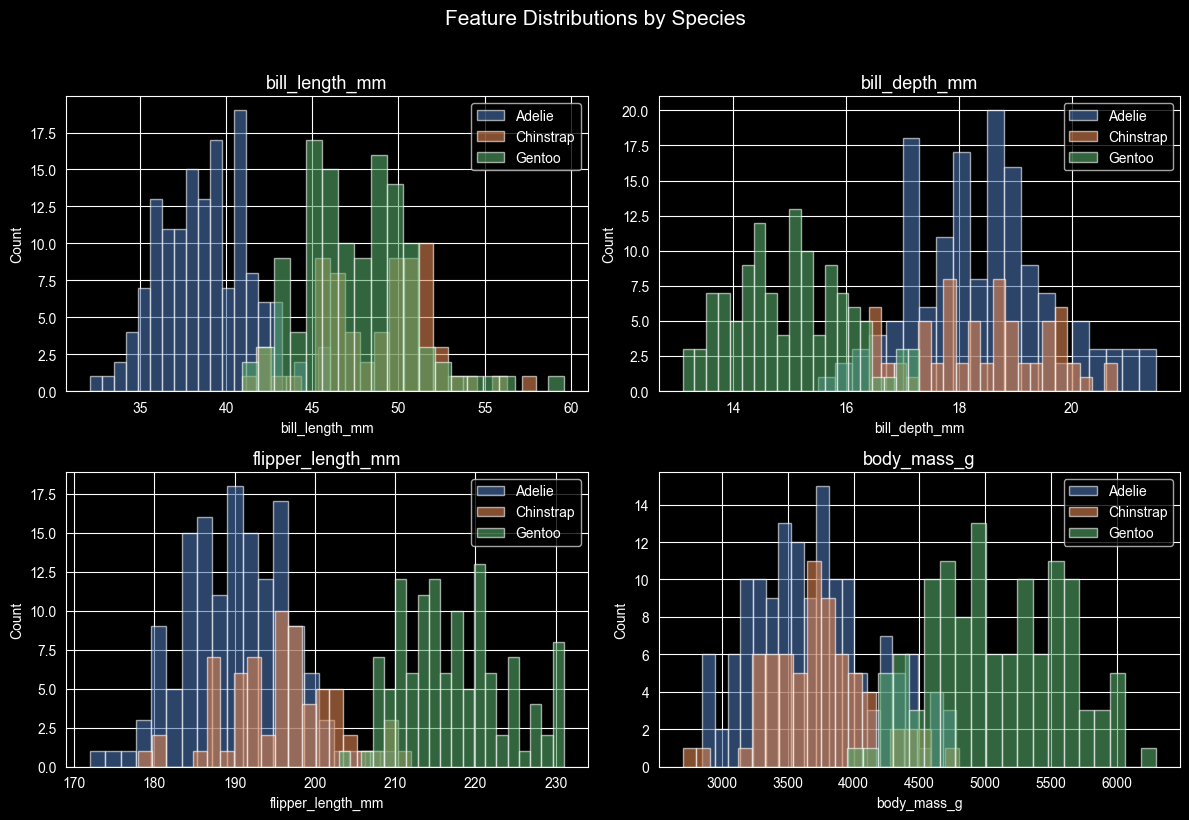

In [9]:
# Distribution overview for each numeric feature
numeric_cols = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    # Plot separate histogram for each species
    for species, color in zip(['Adelie', 'Chinstrap', 'Gentoo'], ['#4C72B0', '#DD8452', '#55A868']):
        subset = df[df['species'] == species][col]
        axes[i].hist(subset, bins=20, alpha=0.6, label=species, color=color)

    axes[i].set_title(col, fontsize=13)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].legend()

plt.suptitle('Feature Distributions by Species', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

## Feature Analysis & Observations

### Discriminative Features
* **Flipper Length:** Offers the **strongest separation**. Gentoos are clearly distinct ($>210\text{mm}$) from Adélie and Chinstrap.
* **Bill Length:** Effectively separates **Adélie** (mostly $<42\text{mm}$) from the other two species.
* **Bill Depth:** High discriminative power for **Gentoos**, who possess much shallower bills despite their larger body size.

### Overlap & Anomalies
* **Species Confusion:** Adélie and Chinstrap overlap significantly in **Body Mass** and **Flipper Length**, meaning the model must rely on bill dimensions to distinguish them.
* **Sexual Dimorphism:** Bimodal peaks within species distributions suggest clear physical differences between males and females.
* **Outliers:** No extreme anomalies detected; a few individuals show high measurements (e.g., long bill lengths), but they remain within biological norms.

## Scale the Numeric Features

**Why scale?** Distance-based algorithms (K-Means, DBSCAN, PCA) are sensitive to feature scale.
Body mass is in grams (~3500–6000) while bill depth is in mm (~13–21). Without scaling,
body mass would completely dominate the distance calculations.

In [10]:
X = df[numeric_cols].values

# Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## Dimensionality Reduction: PCA vs t-SNE

Both methods project our 4D data onto 2D for visualization, but they work differently:
- **PCA**: Linear projection that maximises variance — fast, interpretable axes
- **t-SNE**: Non-linear method that preserves local neighbourhood structure — better at revealing clusters but axes have no meaning

In [11]:
# PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print("PCA Results:")
print(f"  PC1 explains {pca.explained_variance_ratio_[0]:.1%} of variance")
print(f"  PC2 explains {pca.explained_variance_ratio_[1]:.1%} of variance")
print(f"  Combined:    {pca.explained_variance_ratio_.sum():.1%} of variance")

# t-SNE
# perplexity=30 is a good default; max_iter=1000 ensures convergence
tsne = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000)
X_tsne = tsne.fit_transform(X_scaled)

PCA Results:
  PC1 explains 68.6% of variance
  PC2 explains 19.5% of variance
  Combined:    88.1% of variance


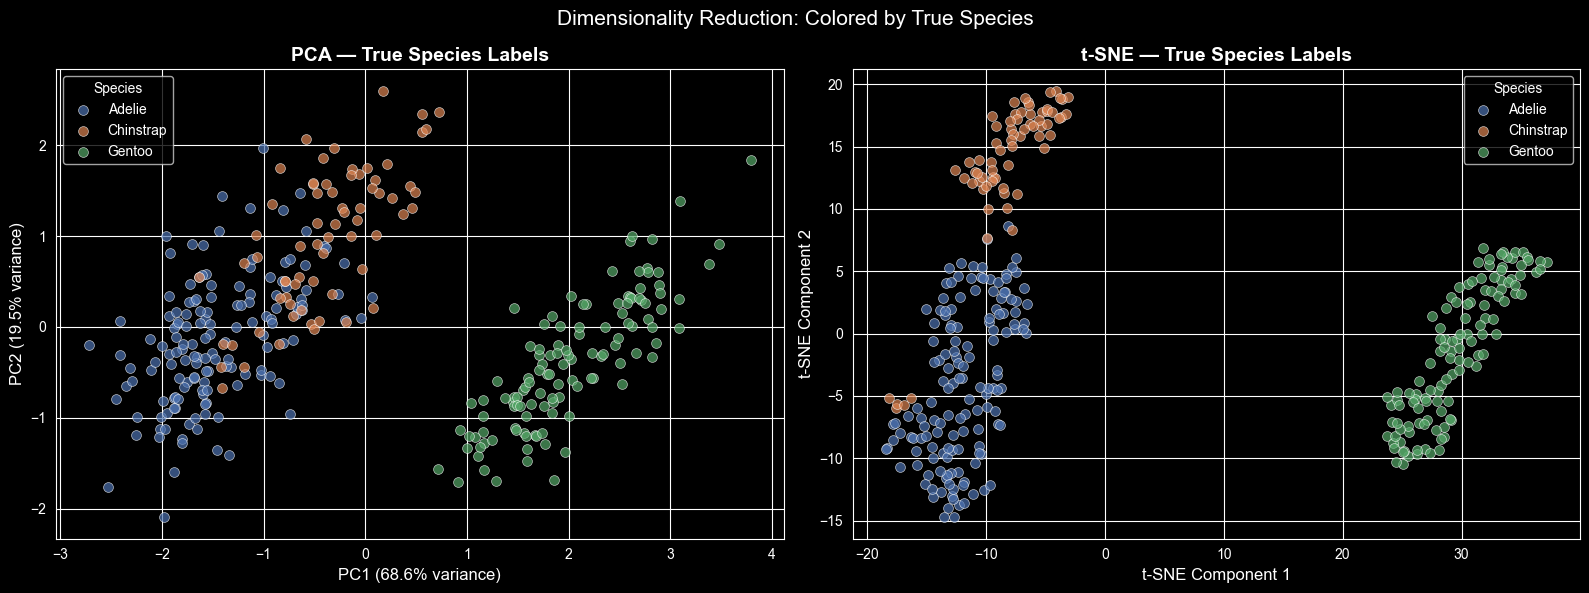

In [12]:
# Side-by-side comparison plot

species_colors = {'Adelie': '#4C72B0', 'Chinstrap': '#DD8452', 'Gentoo': '#55A868'}
colors = df['species'].map(species_colors)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# PCA plot
for species, color in species_colors.items():
    mask = df['species'] == species
    ax1.scatter(X_pca[mask, 0], X_pca[mask, 1],
                c=color, label=species, alpha=0.7, s=50, edgecolors='white', linewidth=0.5)
ax1.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)", fontsize=12)
ax1.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)", fontsize=12)
ax1.set_title("PCA — True Species Labels", fontsize=14, fontweight='bold')
ax1.legend(title='Species')

# t-SNE plot
for species, color in species_colors.items():
    mask = df['species'] == species
    ax2.scatter(X_tsne[mask, 0], X_tsne[mask, 1],
                c=color, label=species, alpha=0.7, s=50, edgecolors='white', linewidth=0.5)
ax2.set_xlabel("t-SNE Component 1", fontsize=12)
ax2.set_ylabel("t-SNE Component 2", fontsize=12)
ax2.set_title("t-SNE — True Species Labels", fontsize=14, fontweight='bold')
ax2.legend(title='Species')

plt.suptitle("Dimensionality Reduction: Colored by True Species", fontsize=15)
plt.tight_layout()
plt.show()

## PCA vs t-SNE Comparison

### 1. Which method separates species better?
**t-SNE** separates the species more clearly than PCA by forming more distinct clusters with clearer gaps between groups.

### 2. Do any species overlap?
Yes.

- **Adelie** and **Chinstrap** overlap, especially in the PCA projection.
- **Gentoo** is well separated and shows almost no overlap with the other species.

## Clustering: K-Means

We know there are 3 species, so we'll use K=3.

In [13]:
# Run K-Means with K=3
# n_init=10 means we try 10 different starting centroids and keep the best run
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

# Evaluate clustering quality
sil_score = silhouette_score(X_scaled, kmeans_labels)
print(f"K-Means Results (K=3):")
print(f"  Silhouette Score:  {sil_score:.4f}")
print(f"  Inertia (WCSS):    {kmeans.inertia_:.2f}")
print(f"  Cluster sizes:     {np.bincount(kmeans_labels)}")

K-Means Results (K=3):
  Silhouette Score:  0.4462
  Inertia (WCSS):    370.77
  Cluster sizes:     [129 119  85]


## Clustering: DBSCAN

DBSCAN takes a completely different approach — it doesn't need you to specify K. Instead, it finds dense regions of points separated by sparse areas.

The two key parameters:
- `eps`: The maximum distance between two points to be considered neighbours
- `min_samples`: Minimum number of points to form a dense region

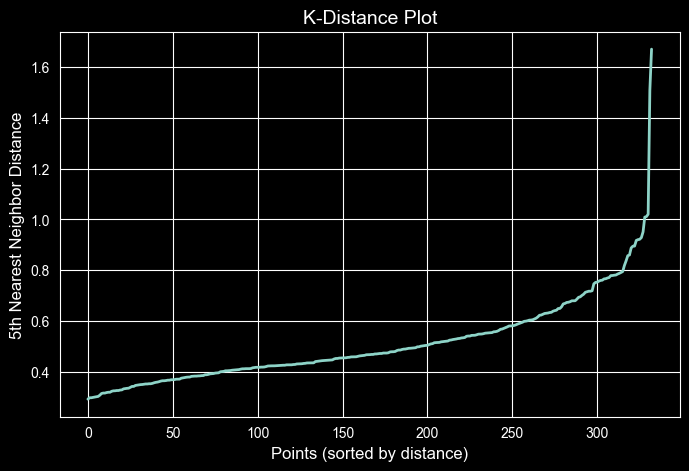

In [14]:
# K-Distance Plot to help choose eps
# For each point, find its 5th nearest neighbour distance.
# The 'elbow' in this sorted plot suggests a good eps value.
from sklearn.neighbors import NearestNeighbors

nn = NearestNeighbors(n_neighbors=5)
nn.fit(X_scaled)
distances, _ = nn.kneighbors(X_scaled)
distances_sorted = np.sort(distances[:, -1])  # 5th neighbour distance, min_samples ≈ D + 1 (D = number of features)

plt.figure(figsize=(8, 5))
plt.plot(distances_sorted, linewidth=2)
plt.xlabel('Points (sorted by distance)', fontsize=12)
plt.ylabel('5th Nearest Neighbor Distance', fontsize=12)
plt.title('K-Distance Plot', fontsize=14)
plt.grid(True)
plt.show()

## Determining `eps` from the K-Distance Plot

- The "elbow" point appears where the curve starts increasing sharply.
- The optimal `eps` range is approximately **0.6–0.8**.

### Interpretation
- **Low values (`eps < 0.5`)**: DBSCAN becomes too strict and labels many penguins as noise.
- **High values (`eps > 1.0`)**: Neighborhoods become too large, causing different species to merge into the same cluster.

In [15]:
# Try 2+ DBSCAN configurations
# Experiment with eps and min_samples to see how results change

dbscan_configs = [
    {'eps': 0.6, 'min_samples': 3},
    {'eps': 0.6, 'min_samples': 5},
    {'eps': 0.7, 'min_samples': 3},
    {'eps': 0.7, 'min_samples': 5},
    {'eps': 0.7, 'min_samples': 7},
    {'eps': 0.8, 'min_samples': 5},
    {'eps': 0.8, 'min_samples': 7},
]

dbscan_results = []

for cfg in dbscan_configs:
    db = DBSCAN(eps=cfg['eps'], min_samples=cfg['min_samples'])
    labels = db.fit_predict(X_scaled)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = (labels == -1).sum()

    # Only compute silhouette if we have 2+ clusters AND some non-noise points
    if n_clusters >= 2 and n_noise < len(labels):
        # Silhouette ignores noise points (label == -1)
        non_noise_mask = labels != -1
        sil = silhouette_score(X_scaled[non_noise_mask], labels[non_noise_mask])
    else:
        sil = None

    dbscan_results.append({
        'config': cfg,
        'labels': labels,
        'n_clusters': n_clusters,
        'n_noise': n_noise,
        'silhouette': sil
    })

    print(
        f"eps={cfg['eps']}, min_samples={cfg['min_samples']} → "
        f"{n_clusters} clusters, {n_noise} noise points, "
        f"silhouette={f'{sil:.4f}' if sil is not None else 'N/A'}"
    )

# Pick the best result (highest silhouette with ≥2 clusters)
best_dbscan = max(
    [r for r in dbscan_results if r['silhouette'] is not None],
    key=lambda x: x['silhouette']
)
dbscan_labels = best_dbscan['labels']
print(f"\nBest DBSCAN config: eps={best_dbscan['config']['eps']}, "
      f"min_samples={best_dbscan['config']['min_samples']}")

eps=0.6, min_samples=3 → 2 clusters, 24 noise points, silhouette=0.5534
eps=0.6, min_samples=5 → 2 clusters, 32 noise points, silhouette=0.5565
eps=0.7, min_samples=3 → 3 clusters, 10 noise points, silhouette=0.4286
eps=0.7, min_samples=5 → 2 clusters, 17 noise points, silhouette=0.5504
eps=0.7, min_samples=7 → 2 clusters, 18 noise points, silhouette=0.5517
eps=0.8, min_samples=5 → 2 clusters, 5 noise points, silhouette=0.5351
eps=0.8, min_samples=7 → 2 clusters, 7 noise points, silhouette=0.5354

Best DBSCAN config: eps=0.6, min_samples=5


## Compare Clustering Results to Ground Truth

Now the key question: how well did unsupervised clustering *rediscover* the true species labels?

We use two metrics:
- **Adjusted Rand Score (ARS)**: Range 0–1. 1.0 = perfect match with true labels
- **Normalized Mutual Information (NMI)**: Range 0–1. 1.0 = perfect information overlap

In [16]:
# Quantitative comparison against true species labels
true_labels = df['species']

# K-Means scores
ars_kmeans = adjusted_rand_score(true_labels, kmeans_labels)
nmi_kmeans = normalized_mutual_info_score(true_labels, kmeans_labels)
print(f"K-Means (K=3):")
print(f"  Adjusted Rand Score:  {ars_kmeans:.4f}")
print(f"  Normalized Mutual Info: {nmi_kmeans:.4f}")

# DBSCAN scores (compare only non-noise points)
non_noise = dbscan_labels != -1
if non_noise.sum() > 0:
    ars_dbscan = adjusted_rand_score(true_labels[non_noise], dbscan_labels[non_noise])
    nmi_dbscan = normalized_mutual_info_score(true_labels[non_noise], dbscan_labels[non_noise])
    print(f"\nDBSCAN (best config, non-noise only):")
    print(f"  Adjusted Rand Score:    {ars_dbscan:.4f}")
    print(f"  Normalized Mutual Info: {nmi_dbscan:.4f}")
    print(f"  Points classified as noise: {(~non_noise).sum()} / {len(dbscan_labels)}")

K-Means (K=3):
  Adjusted Rand Score:  0.7994
  Normalized Mutual Info: 0.7899

DBSCAN (best config, non-noise only):
  Adjusted Rand Score:    0.6691
  Normalized Mutual Info: 0.7732
  Points classified as noise: 32 / 333


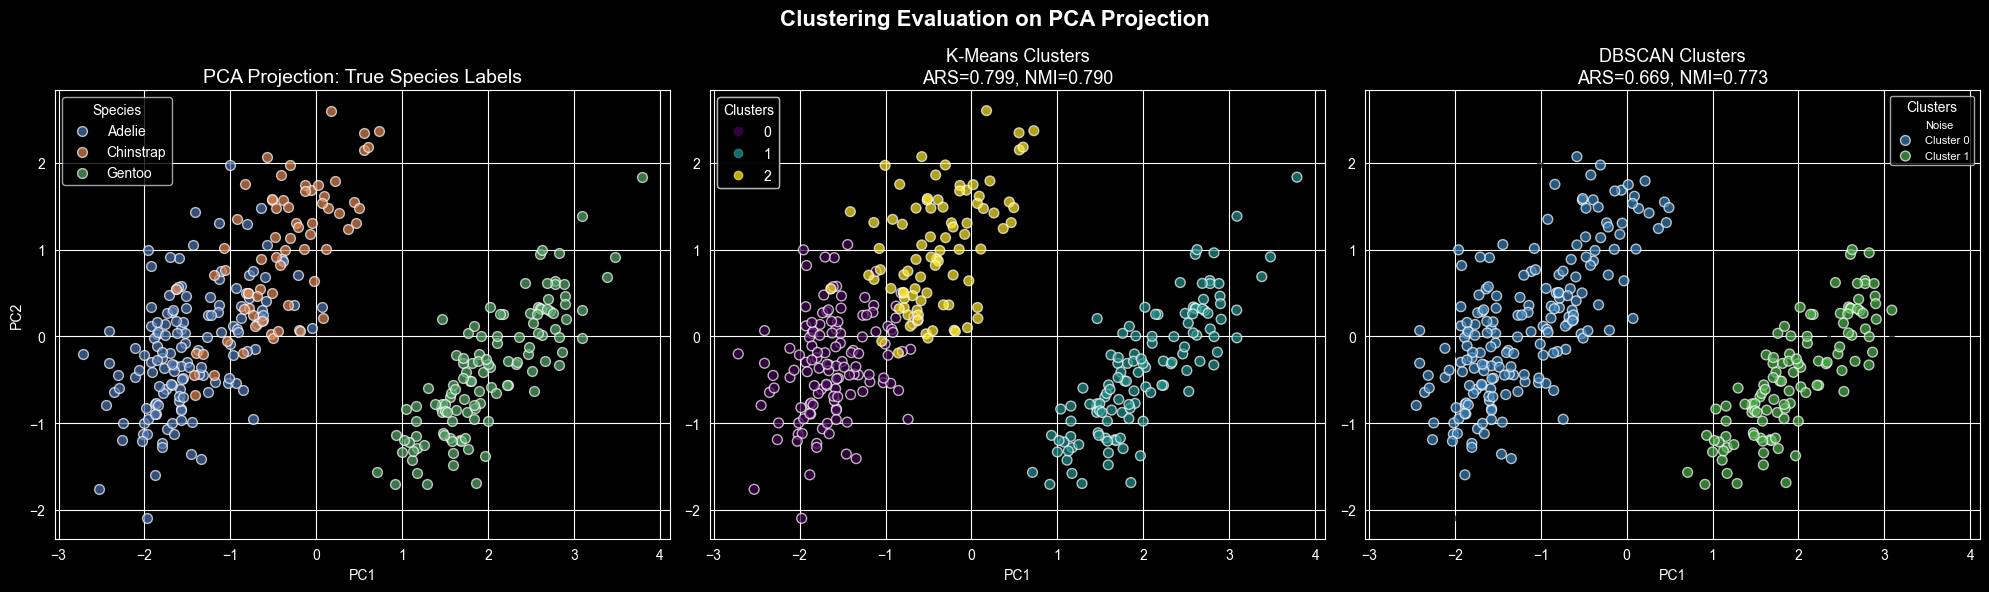

In [17]:
# Compare True Labels vs Best Clustering on PCA Projection

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Plot 1: True Species Labels
species_colors = {
    'Adelie': '#4C72B0',
    'Chinstrap': '#DD8452',
    'Gentoo': '#55A868'
}

for species, color in species_colors.items():
    mask = df['species'] == species
    axes[0].scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        c=color,
        label=species,
        alpha=0.7,
        s=50,
        edgecolors='white'
    )

axes[0].set_title("PCA Projection: True Species Labels", fontsize=14)
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].legend(title='Species')


# Plot 2: K-Means Clusters
scatter1 = axes[1].scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=kmeans_labels,
    cmap='viridis',
    alpha=0.7,
    s=50,
    edgecolors='white'
)

axes[1].set_title(
    f"K-Means Clusters\nARS={ars_kmeans:.3f}, NMI={nmi_kmeans:.3f}",
    fontsize=13
)
axes[1].set_xlabel("PC1")

legend1 = axes[1].legend(
    *scatter1.legend_elements(),
    title="Clusters"
)
axes[1].add_artist(legend1)


# Plot 3: DBSCAN Clusters
unique_db_labels = sorted(set(dbscan_labels))
palette = plt.cm.Set1.colors

for j, label in enumerate(unique_db_labels):

    mask = dbscan_labels == label

    color = 'black' if label == -1 else palette[j % len(palette)]
    cluster_name = 'Noise' if label == -1 else f'Cluster {label}'

    axes[2].scatter(
        X_pca[mask, 0],
        X_pca[mask, 1],
        c=[color] * mask.sum(),
        label=cluster_name,
        alpha=0.7,
        s=20 if label == -1 else 50,
        marker='x' if label == -1 else 'o',
        edgecolors='white'
    )

axes[2].set_title(
    f"DBSCAN Clusters\nARS={ars_dbscan:.3f}, NMI={nmi_dbscan:.3f}",
    fontsize=13
)
axes[2].set_xlabel("PC1")
axes[2].legend(title='Clusters', fontsize=8)


# ── Main Title ──
plt.suptitle(
    "Clustering Evaluation on PCA Projection",
    fontsize=16,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

### Summary: Unsupervised Species Recovery

**1. Recovery Success**
* **High Accuracy:** Unsupervised methods recovered the species structure with high reliability (**K-Means ARS: 0.7994**).
* **Gentoo Isolation:** Both algorithms perfectly separated **Gentoo** penguins because they are morphologically distinct, forming a clearly isolated cluster in the PCA projection.
* **K-Means Performance:** K-Means outperformed DBSCAN by successfully partitioning the larger data cloud into two distinct groups (Adelie and Chinstrap) using centroid-based logic.

**2. Points of Failure**
* **Feature Overlap:** Both methods struggled with the **Adelie-Chinstrap overlap**. Because these species share similar physical dimensions, there is no "natural gap" for the algorithms to find.
* **DBSCAN Density:** DBSCAN ($ARS: 0.6691$) failed to distinguish between Adelie and Chinstrap, likely viewing them as one continuous density-connected blob.
* **Noise Handling:** DBSCAN labeled **32 points as noise**. While these are statistical outliers, they represent real penguins that the model failed to categorize.

**3. Quantitative Summary**
| Metric | K-Means (K=3) | DBSCAN (Non-noise) |
| :--- | :--- | :--- |
| **Adjusted Rand Score** | **0.7994** | 0.6691 |
| **Normalized Mutual Info** | **0.7899** | 0.7732 |
| **Noise Points** | 0 | 32 / 333 |

**Conclusion:** The recovery was successful for distinct species, but hit a mathematical ceiling where biological traits naturally overlap.

## Task 2 — Supervised Model Pipeline

## Prepare Features & Target

In [18]:
# We use the cleaned df from Task 1 (rows with NaN already removed)
# Target: species (what we want to predict)
# Features: everything else

target = 'species'
feature_cols = [col for col in df.columns if col != target]

print("Feature columns:", feature_cols)
print("Target column:  ", target)

X = df.drop(target, axis=1)
y = df[target]

print(f"\nDataset shape: {X.shape}")
print("\nClass distribution:")
print(y.value_counts())

# Identify which columns are numeric vs categorical
numeric_features = X.select_dtypes(include=['number']).columns.tolist()
categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"\nNumeric features ({len(numeric_features)}):    {numeric_features}")
print(f"Categorical features ({len(categorical_features)}): {categorical_features}")

Feature columns: ['island', 'bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'sex']
Target column:   species

Dataset shape: (333, 6)

Class distribution:
species
Adelie       146
Gentoo       119
Chinstrap     68
Name: count, dtype: int64

Numeric features (4):    ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
Categorical features (2): ['island', 'sex']


In [19]:
# Train/Test Split
# stratify=y ensures each species is proportionally represented in both sets
# This is critical for imbalanced or multi-class data

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y        # keeps class ratios equal in both splits
)

print(f"Training set:  {X_train.shape[0]} samples ({X_train.shape[0]/len(X):.0%})")
print(f"Test set:      {X_test.shape[0]} samples ({X_test.shape[0]/len(X):.0%})")

print("\nClass distribution in training set:")
print(y_train.value_counts())

print("\nClass distribution in test set:")
print(y_test.value_counts())

Training set:  266 samples (80%)
Test set:      67 samples (20%)

Class distribution in training set:
species
Adelie       117
Gentoo        95
Chinstrap     54
Name: count, dtype: int64

Class distribution in test set:
species
Adelie       29
Gentoo       24
Chinstrap    14
Name: count, dtype: int64


In [20]:
# Fit encoder on training and test labels and transform them to numeric values (e.g., Adelie → 0, Chinstrap → 1, Gentoo → 2)
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

## Build the Preprocessing Pipeline

A `ColumnTransformer` applies different transformations to different column types:
- **Numeric columns** → `StandardScaler` (subtract mean, divide by std)
- **Categorical columns** → `OneHotEncoder` (convert strings to binary columns)

Wrapping this in a `Pipeline` ensures preprocessing is always applied consistently — including at prediction time.

In [21]:
# Build preprocessing ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        # name, transformer, columns
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features),
    ],
    remainder='drop'    # drop any columns not listed above
)

# Quick sanity check: fit on training data and see output shape
X_train_transformed = preprocessor.fit_transform(X_train)
print("Preprocessing check:")
print(f"  Input shape:  {X_train.shape}")
print(f"  Output shape: {X_train_transformed.shape}")

# Get feature names after transformation (for later interpretability)
num_feature_names = numeric_features
cat_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features).tolist()
all_feature_names = num_feature_names + cat_feature_names
print(f"\nAll feature names after preprocessing:")
for name in all_feature_names:
    print(f"  - {name}")

Preprocessing check:
  Input shape:  (266, 6)
  Output shape: (266, 9)

All feature names after preprocessing:
  - bill_length_mm
  - bill_depth_mm
  - flipper_length_mm
  - body_mass_g
  - island_Biscoe
  - island_Dream
  - island_Torgersen
  - sex_Female
  - sex_Male


## Compare 4 Models with Cross-Validation

We use **Stratified 5-Fold CV** on the training set. This means:
1. The training set is split into 5 folds
2. Each model trains 5 times, each time using a different fold as validation
3. We average the 5 scores for a reliable estimate

We **do not touch the test set** yet — that's only for final evaluation in Task 3.

In [22]:
# Define 4 candidate models
# Each is wrapped in a Pipeline with the preprocessor so it's fully self-contained

models = {
    'Logistic Regression': Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression(max_iter=1000, random_state=42))
    ]),
    'Random Forest': Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
    ]),
    'SVM': Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', SVC(probability=True, random_state=42))
    ]),
    'XGBoost': Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', XGBClassifier(eval_metric='mlogloss', random_state=42))
    ])
}

# Stratified 5-Fold CV setup
# Using the same cv object for all models ensures fair comparison
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Evaluate each model
results = {}
metrics = ['accuracy', 'precision_macro', 'recall_macro', 'f1_macro']

print("Evaluating models with 5-fold stratified cross-validation\n")

for model_name, pipeline in models.items():
    print(f"{model_name}")
    results[model_name] = {}

    for metric in metrics:
        # cross_val_score returns one score per fold
        scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring=metric)
        results[model_name][metric] = {
            'mean': scores.mean(),
            'std': scores.std()
        }

Evaluating models with 5-fold stratified cross-validation

Logistic Regression
Random Forest
SVM
XGBoost


In [23]:
# Print results table
print(f"{'Model':<22} {'Accuracy':>12} {'Precision':>12} {'Recall':>12} {'F1':>12}")

for model_name, scores in results.items():
    acc  = scores['accuracy']['mean']
    prec = scores['precision_macro']['mean']
    rec  = scores['recall_macro']['mean']
    f1   = scores['f1_macro']['mean']
    f1_std = scores['f1_macro']['std']
    print(f"{model_name:<22} {acc:>12.4f} {prec:>12.4f} {rec:>12.4f} {f1:>10.4f} ± {f1_std:.4f}")

Model                      Accuracy    Precision       Recall           F1
Logistic Regression          0.9963       0.9973       0.9939     0.9955 ± 0.0091
Random Forest                0.9887       0.9885       0.9851     0.9863 ± 0.0112
SVM                          0.9925       0.9946       0.9879     0.9909 ± 0.0112
XGBoost                      0.9850       0.9857       0.9790     0.9817 ± 0.0092


In [24]:
# Select the best model based on F1 score
best_model_name = max(results, key=lambda m: results[m]['f1_macro']['mean'])
best_baseline_f1 = results[best_model_name]['f1_macro']['mean']
best_pipeline = models[best_model_name]

print(f"Best model: {best_model_name}")
print(f"   F1 Score (macro, CV): {best_baseline_f1:.4f}")

Best model: Logistic Regression
   F1 Score (macro, CV): 0.9955


## Hyperparameter Tuning with GridSearchCV

In [25]:
# Define hyperparameter grids for each possible best model
# The grid uses Pipeline notation: "stepname__parametername"

param_grids = {
    'Logistic Regression': {
        'classifier__C': [0.01, 0.1, 1.0, 10.0, 100.0],
        'classifier__solver': ['lbfgs', 'saga'],
        'classifier__max_iter': [500, 1000]
    },
    'Random Forest': {
        'classifier__n_estimators': [50, 100, 200],
        'classifier__max_depth': [5, 10, None],
        'classifier__min_samples_split': [2, 5, 10]
    },
    'SVM': {
        'classifier__C': [0.1, 1.0, 10.0, 100.0],
        'classifier__kernel': ['rbf', 'linear'],
        'classifier__gamma': ['scale', 'auto']
    },
    'XGBoost': {
        'classifier__n_estimators': [50, 100, 150],
        'classifier__learning_rate': [0.01, 0.1, 0.2],
        'classifier__max_depth': [3, 5, 7],
        'classifier__subsample': [0.8, 1.0]
    }
}

chosen_grid = param_grids[best_model_name]

print(f"Tuning: {best_model_name}")
print(f"Parameter grid:")
for param, values in chosen_grid.items():
    print(f"  {param}: {values}")

total_combos = 1
for values in chosen_grid.values():
    total_combos *= len(values)
print(f"\nTotal combinations: {total_combos}")
print(f"Total model fits:   {total_combos * 5} (combinations × 5 folds)")

Tuning: Logistic Regression
Parameter grid:
  classifier__C: [0.01, 0.1, 1.0, 10.0, 100.0]
  classifier__solver: ['lbfgs', 'saga']
  classifier__max_iter: [500, 1000]

Total combinations: 20
Total model fits:   100 (combinations × 5 folds)


In [26]:
# Run GridSearchCV

print(f"Running GridSearchCV for {best_model_name}")

grid_search = GridSearchCV(
    estimator=best_pipeline,
    param_grid=chosen_grid,
    cv=cv,                   # same stratified 5-fold CV as before
    scoring='f1_macro',      # optimise for macro F1
    n_jobs=-1,               # use all CPU cores
    verbose=1,               # show progress
    refit=True               # refit best model on full training set after search
)

grid_search.fit(X_train, y_train)

# Print results
print("  GridSearchCV Results")
print(f"Best parameters:")
for param, value in grid_search.best_params_.items():
    print(f"  {param}: {value}")
print(f"\nBest CV F1 Score (tuned):   {grid_search.best_score_:.4f}")
print(f"Baseline CV F1 Score:        {best_baseline_f1:.4f}")
improvement = grid_search.best_score_ - best_baseline_f1
print(f"Improvement from tuning:     {improvement:+.4f}")

# The best estimator is now stored in grid_search.best_estimator_
tuned_model = grid_search.best_estimator_

Running GridSearchCV for Logistic Regression
Fitting 5 folds for each of 20 candidates, totalling 100 fits
  GridSearchCV Results
Best parameters:
  classifier__C: 1.0
  classifier__max_iter: 500
  classifier__solver: lbfgs

Best CV F1 Score (tuned):   0.9955
Baseline CV F1 Score:        0.9955
Improvement from tuning:     +0.0000


## Logistic Regression: Hyperparameter Optimization Report

### Best Parameter Configuration

The exhaustive grid search identified the following hyperparameters as the optimal configuration for the model:

* **Regularization Strength ($C$):** 1.0
* **Maximum Iterations:** 500
* **Optimization Algorithm:** `lbfgs`


### Performance Metrics

The model performance was evaluated using the **F1 Score** to ensure a robust balance between precision and recall during cross-validation.

| Metric | Score |
| --- | --- |
| **Best CV F1 Score (Tuned)** | **0.9955** |
| **Baseline CV F1 Score** | **0.9955** |


### Comparative Analysis

A side-by-side comparison reveals that the hyperparameter tuning process yielded results identical to the baseline configuration:

* **Absolute Improvement:** +0.0000
* **Performance Delta:** 0%


### Technical Interpretation

The convergence of the tuned and baseline scores suggests that the default settings of the **Logistic Regression** estimator were already perfectly aligned with the underlying structure of the dataset.

The near-perfect F1 score of **0.9955** indicates that the feature space is highly informative and linearly separable. In this scenario, the model has reached a performance ceiling where further parameter manipulation offers diminishing returns, confirming that the initial model architecture was sufficient for the classification task.

## Task 3 — Model Evaluation & Interpretation

## Final Test Set Evaluation

In [27]:
# Final evaluation
# The tuned model was already refit on the full training set by GridSearchCV (because we set refit=True above)

y_pred = tuned_model.predict(X_test)
y_proba = tuned_model.predict_proba(X_test)

classes = tuned_model.classes_  # ['Adelie', 'Chinstrap', 'Gentoo']

print("  FINAL TEST SET EVALUATION")
print(f"\nAccuracy:           {(y_pred == y_test).mean():.4f}")
print(f"F1 Score (macro):   {f1_score(y_test, y_pred, average='macro'):.4f}")
print(f"Precision (macro):  {precision_score(y_test, y_pred, average='macro'):.4f}")
print(f"Recall (macro):     {recall_score(y_test, y_pred, average='macro'):.4f}")
print('')
print("CLASSIFICATION REPORT (per species):")
print(classification_report(y_test, y_pred, digits=4))

  FINAL TEST SET EVALUATION

Accuracy:           0.9851
F1 Score (macro):   0.9827
Precision (macro):  0.9778
Recall (macro):     0.9885

CLASSIFICATION REPORT (per species):
              precision    recall  f1-score   support

           0     1.0000    0.9655    0.9825        29
           1     0.9333    1.0000    0.9655        14
           2     1.0000    1.0000    1.0000        24

    accuracy                         0.9851        67
   macro avg     0.9778    0.9885    0.9827        67
weighted avg     0.9861    0.9851    0.9852        67



## Confusion Matrix

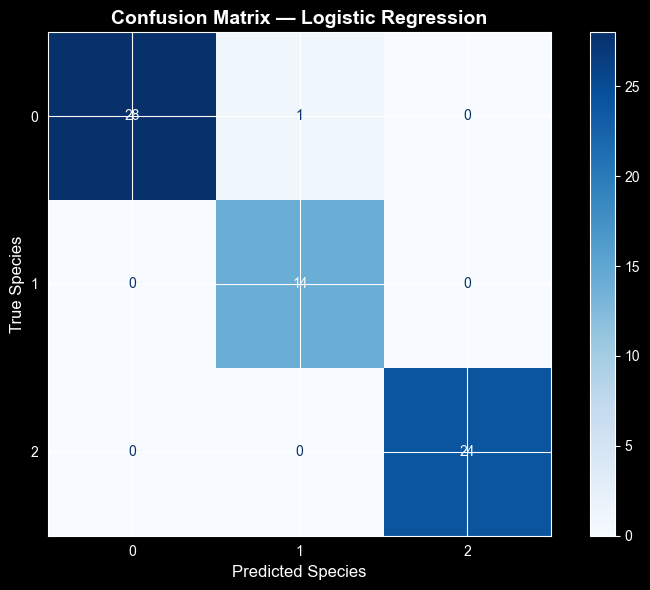

In [28]:
fig, ax = plt.subplots(figsize=(8, 6))

cm = confusion_matrix(y_test, y_pred, labels=classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(ax=ax, cmap='Blues', colorbar=True)

ax.set_title(f'Confusion Matrix — {best_model_name}', fontsize=14, fontweight='bold')
ax.set_xlabel('Predicted Species', fontsize=12)
ax.set_ylabel('True Species', fontsize=12)

plt.tight_layout()
plt.show()

## ROC Curves (One-vs-Rest for All 3 Species)

ROC curves show the trade-off between true positive rate (recall) and false positive rate at different classification thresholds. The **AUC** (Area Under Curve) summarises the curve.

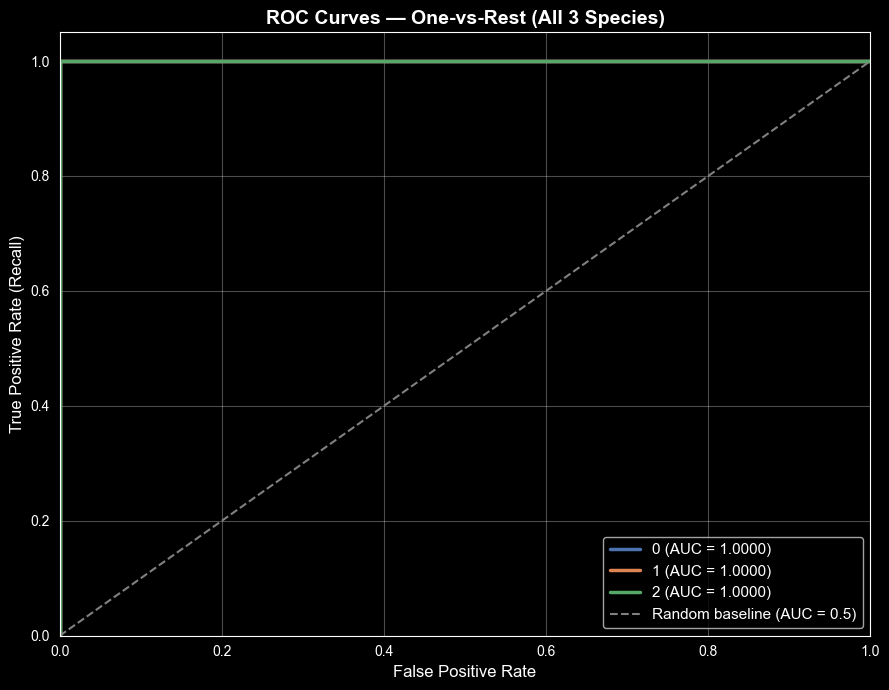

Weighted ROC-AUC (overall): 1.0000


In [29]:
# Binarise true labels for one-vs-rest ROC (needed for multi-class)
y_test_bin = label_binarize(y_test, classes=classes)

fig, ax = plt.subplots(figsize=(9, 7))

species_colors_roc = {'Adelie': '#4C72B0', 'Chinstrap': '#DD8452', 'Gentoo': '#55A868'}

for i, (species, color) in enumerate(zip(classes, species_colors_roc.values())):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, linewidth=2.5,
            label=f'{species} (AUC = {roc_auc:.4f})')

# Random baseline (diagonal line)
ax.plot([0, 1], [0, 1], color='gray', linestyle='--', linewidth=1.5,
        label='Random baseline (AUC = 0.5)')

ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate (Recall)', fontsize=12)
ax.set_title('ROC Curves — One-vs-Rest (All 3 Species)', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Overall weighted AUC
overall_auc = roc_auc_score(y_test_bin, y_proba, multi_class='ovr', average='weighted')
print(f"Weighted ROC-AUC (overall): {overall_auc:.4f}")

## Learning Curves

Learning curves show model performance as training size increases. They help diagnose:
- **High bias (underfitting)**: Both curves converge at a low score
- **High variance (overfitting)**: Large gap between train and validation scores
- **Good fit**: Both curves converge at a high score with a small gap

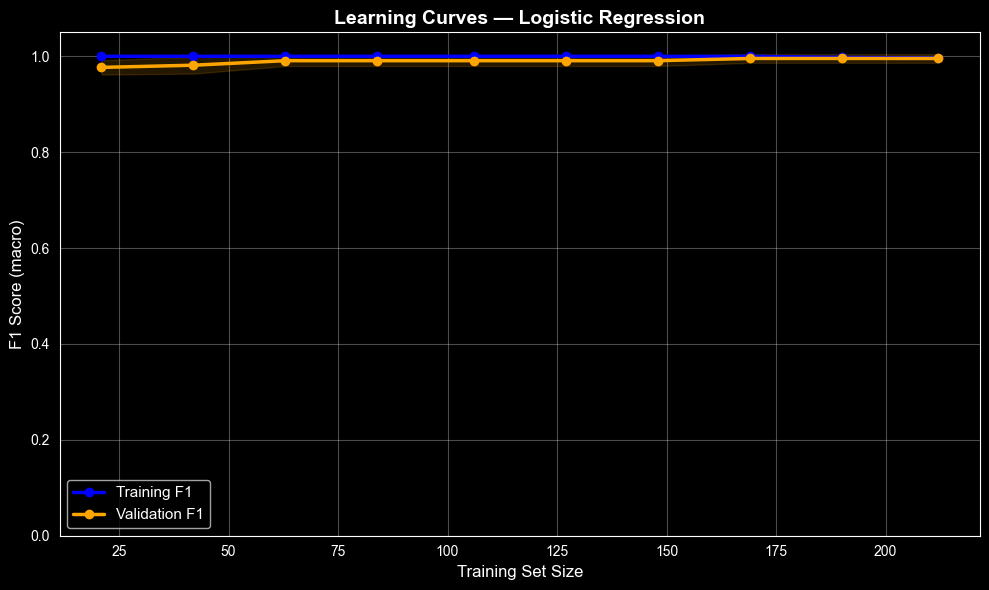

Final train score:      0.9966
Final validation score: 0.9955
Gap: 0.0011 (< 0.05 is generally acceptable)


In [30]:
train_sizes, train_scores, val_scores = learning_curve(
    tuned_model,
    X_train, y_train,
    cv=cv,
    train_sizes=np.linspace(0.1, 1.0, 10),  # 10% → 100% of training data
    scoring='f1_macro',
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(10, 6))

# Shaded bands show ±1 standard deviation across folds
ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std,
                alpha=0.15, color='blue')
ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std,
                alpha=0.15, color='orange')

ax.plot(train_sizes, train_mean, 'o-', color='blue', linewidth=2.5,
        label='Training F1', markersize=6)
ax.plot(train_sizes, val_mean, 'o-', color='orange', linewidth=2.5,
        label='Validation F1', markersize=6)

ax.set_xlabel('Training Set Size', fontsize=12)
ax.set_ylabel('F1 Score (macro)', fontsize=12)
ax.set_title(f'Learning Curves — {best_model_name}', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_ylim([0, 1.05])

plt.tight_layout()
plt.show()

# Print final gap
final_gap = train_mean[-1] - val_mean[-1]
print(f"Final train score:      {train_mean[-1]:.4f}")
print(f"Final validation score: {val_mean[-1]:.4f}")
print(f"Gap: {final_gap:.4f} (< 0.05 is generally acceptable)")

## Permutation Feature Importances

Permutation importance measures how much the model's F1 drops when we randomly shuffle one feature at a time.

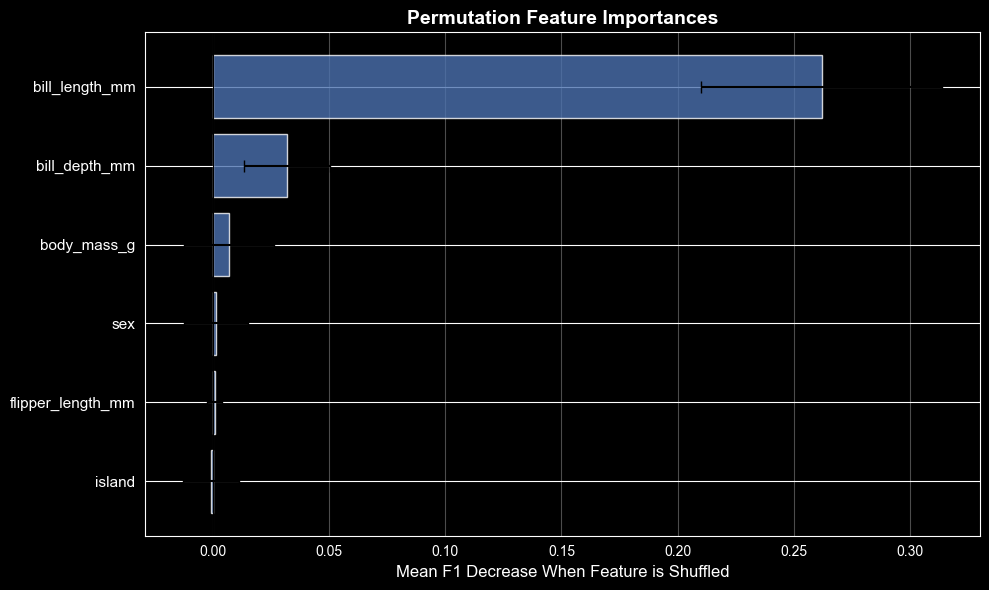

Top 5 most important features:
  1. bill_length_mm: 0.2619 ± 0.0519
  2. bill_depth_mm: 0.0320 ± 0.0184
  3. body_mass_g: 0.0068 ± 0.0193
  4. sex: 0.0014 ± 0.0136
  5. flipper_length_mm: 0.0009 ± 0.0032


In [31]:
perm_imp = permutation_importance(
    tuned_model, X_test, y_test,
    n_repeats=15,              # shuffle each feature 15 times for stable estimates
    random_state=42,
    scoring='f1_macro',
    n_jobs=-1
)

# Get feature names (the raw inputs that were shuffled)
feature_names = np.array(X_test.columns.tolist())

# Sort by mean importance (descending)
sorted_idx = perm_imp.importances_mean.argsort()[::-1]

# Plot top features
n_top = min(10, len(feature_names))
top_idx = sorted_idx[:n_top]

fig, ax = plt.subplots(figsize=(10, 6))

# Horizontal bar plot
ax.barh(range(n_top),
        perm_imp.importances_mean[top_idx][::-1],
        xerr=perm_imp.importances_std[top_idx][::-1],
        color='#4C72B0', alpha=0.8, capsize=4)

ax.set_yticks(range(n_top))
ax.set_yticklabels(feature_names[top_idx][::-1], fontsize=11)
ax.set_xlabel('Mean F1 Decrease When Feature is Shuffled', fontsize=12)
ax.set_title(f'Permutation Feature Importances', fontsize=14, fontweight='bold')
ax.axvline(x=0, color='black', linewidth=0.8)
ax.grid(True, axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print("Top 5 most important features:")
for i, idx in enumerate(top_idx[:5]):
    print(f"  {i+1}. {feature_names[idx]}: {perm_imp.importances_mean[idx]:.4f} ± {perm_imp.importances_std[idx]:.4f}")

### Model Interpretation: Comprehensive Analysis

---

**1. Overfitting or Underfitting?**

The model is **well-balanced** and demonstrates excellent generalization. The final training score is **0.9966** while the validation score is **0.9955**, resulting in a minimal gap of only **0.0011**. As shown in the learning curves, the training and validation F1-scores converge quickly and stay close as the training set size increases, indicating that the model is neither overfitting nor underfitting.

---

**2. Which Species Is Hardest to Classify?**

Based on the classification report and confusion matrix, **Species 1 (Chinstrap)** is the hardest to classify relatively.

* While it achieved a perfect recall of **1.0000**, it has the lowest precision at **0.9333**.
* The confusion matrix shows that one instance of **Species 0 (Adelie)** was misclassified as **Species 1**.
* This confusion mirrors the findings in Task 1, where Adelie and Chinstrap penguins showed significant feature distribution overlap in the PCA projection.

---

**3. Which Features Drive Predictions?**

According to the permutation importances, the top 3 features driving the model's predictions are:

1. **bill_length_mm**: $0.2619 \pm 0.0519$
2. **bill_depth_mm**: $0.0320 \pm 0.0184$
3. **body_mass_g**: $0.0068 \pm 0.0193$

These results align with biological intuition, as bill dimensions are primary differentiators between these species.

---

**4. Data Leakage or Evaluation Issues?**

The evaluation process appears robust with no signs of data leakage.

* **Stratification**: A **Stratified 5-Fold CV** was used to maintain class proportions.
* **Isolation**: The **80/20 split** was established early, ensuring the test set remained a "held-out" set for final evaluation only.
* **Pipeline Integrity**: The use of a `ColumnTransformer` within a `Pipeline` ensured that the `StandardScaler` was fit only on training folds, preventing information from the test set from leaking into the training phase.

---

**5. ROC Curves Analysis**

All three species achieved a perfect **AUC of 1.0000**.

* An AUC close to **1.0** indicates that the model has a near-perfect ability to distinguish between each species and the others across all classification thresholds.
* The **Weighted ROC-AUC** for the entire model is also **1.0000**, confirming superior separability across the entire dataset.

## Task 4 — Model Deployment Prototype

## Serialize the Trained Pipeline

In [32]:
# Save the full pipeline (preprocessor + model)
# We save the entire pipeline, not just the model.
# This means the saved file knows how to preprocess new data automatically.

model_path = 'penguin_pipeline.joblib'

joblib.dump(tuned_model, model_path)

file_size_kb = os.path.getsize(model_path) / 1024
print(f"Full pipeline saved to: {model_path}")
print(f"File size: {file_size_kb:.1f} KB")

# Save metadata alongside the model
# This documents what the model expects as input
metadata = {
    'model_type': best_model_name,
    'version': '1.0.0',
    'numeric_features': numeric_features,
    'categorical_features': categorical_features,
    'target_classes': le.classes_.tolist(),
    'best_params': {k: (v.item() if hasattr(v, 'item') else v) for k, v in grid_search.best_params_.items()},
    'cv_f1_score': float(round(grid_search.best_score_, 4)),
    'test_f1_score': float(round(f1_score(y_test, y_pred, average='macro'), 4))
}

with open('model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print("\nMetadata saved to: model_metadata.json")
print("\nMetadata content:")
print(json.dumps(metadata, indent=2))

Full pipeline saved to: penguin_pipeline.joblib
File size: 3.8 KB

Metadata saved to: model_metadata.json

Metadata content:
{
  "model_type": "Logistic Regression",
  "version": "1.0.0",
  "numeric_features": [
    "bill_length_mm",
    "bill_depth_mm",
    "flipper_length_mm",
    "body_mass_g"
  ],
  "categorical_features": [
    "island",
    "sex"
  ],
  "target_classes": [
    "Adelie",
    "Chinstrap",
    "Gentoo"
  ],
  "best_params": {
    "classifier__C": 1.0,
    "classifier__max_iter": 500,
    "classifier__solver": "lbfgs"
  },
  "cv_f1_score": 0.9955,
  "test_f1_score": 0.9827
}


In [33]:
# Sanity check: load the saved model and verify it works
loaded_model = joblib.load(model_path)

# Test prediction on a small sample from the test set
test_sample = X_test.head(3)
loaded_predictions = loaded_model.predict(test_sample)
original_predictions = tuned_model.predict(test_sample)

print("Loaded model predictions match original:", np.all(loaded_predictions == original_predictions))
print("Sample predictions:", loaded_predictions)

Loaded model predictions match original: True
Sample predictions: [2 1 0]


## Create the Flask API (`app.py`)

In [34]:
app_code = '''
from flask import Flask, request, jsonify
import joblib
import pandas as pd
import numpy as np

app = Flask(__name__)

# Load the serialized pipeline at startup
model = joblib.load("penguin_pipeline.joblib")

# Feature definitions
NUMERIC_FEATURES = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]
CATEGORICAL_FEATURES = ["island", "sex"]
ALL_FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES

@app.route("/health", methods=["GET"])
def health():
    return jsonify({"status": "healthy", "model_version": "1.0.0"})

@app.route("/predict", methods=["POST"])
def predict():
    # 1. Parse JSON
    data = request.get_json(silent=True)
    if not data:
        return jsonify({"error": "Request body must be valid JSON"}), 400

    # 2. Validate all required fields
    missing = [f for f in ALL_FEATURES if f not in data]
    if missing:
        return jsonify({"error": f"Missing required fields: {missing}"}), 400

    # 3. Validate types
    for feat in NUMERIC_FEATURES:
        if not isinstance(data[feat], (int, float)):
            return jsonify({"error": f"Field '{feat}' must be a number"}), 400
    for feat in CATEGORICAL_FEATURES:
        if not isinstance(data[feat], str):
            return jsonify({"error": f"Field '{feat}' must be a string"}), 400

    # 4. Predict (One single Try/Except block)
    try:
        input_df = pd.DataFrame([data])[ALL_FEATURES]

        # Convert NumPy types to Python types for JSON compatibility
        raw_prediction = model.predict(input_df)[0]
        prediction = raw_prediction.item() if hasattr(raw_prediction, 'item') else int(raw_prediction)

        probabilities = model.predict_proba(input_df)[0]
        classes = model.classes_

        return jsonify({
            "prediction": prediction,
            "probabilities": {
                str(cls): round(float(prob), 4)
                for cls, prob in zip(classes, probabilities)
            },
            "model_version": "1.0.0"
        })

    except Exception as e:
        return jsonify({"error": f"Prediction failed: {str(e)}"}), 500

@app.errorhandler(404)
def not_found(e):
    return jsonify({"error": "Endpoint not found"}), 404

if __name__ == "__main__":
    app.run(host="0.0.0.0", port=5000, debug=True)
'''

with open('app.py', 'w') as f:
    f.write(app_code)

## Test the API from This Notebook

In [39]:
# Test 1: Health check
# This confirms the server is running

import requests

try:
    response = requests.get("http://localhost:5000/health", timeout=3)
    print(f"Status code: {response.status_code}")
    print(f"Response:    {response.json()}")
    print("\nServer is running!")
except requests.exceptions.ConnectionError:
    print("Server not running. Start it with: python app.py")
    print("(Expected response when running: {'status': 'healthy', 'model_version': '1.0.0'})")

Status code: 200
Response:    {'model_version': '1.0.0', 'status': 'healthy'}

Server is running!


In [40]:
# Test 2: Valid prediction request
# Sending a real penguin's measurements

valid_penguin = {
    "bill_length_mm": 39.1,
    "bill_depth_mm": 18.7,
    "flipper_length_mm": 181.0,
    "body_mass_g": 3750.0,
    "island": "Torgersen",
    "sex": "Male"
}

try:
    response = requests.post(
        "http://localhost:5000/predict",
        json=valid_penguin,
        timeout=5
    )

    print(f"Status code: {response.status_code}")
    result = response.json()
    print(f"Prediction:  {result.get('prediction')}")
    print(f"Probabilities:")
    for species, prob in result.get('probabilities', {}).items():
        bar = '█' * int(prob * 30)
        print(f"  {species:<12} {bar:<30} {prob:.4f}")

    print("\nValid prediction request worked!")
except requests.exceptions.ConnectionError:
    print("Server not running. Expected response:")
    # Show what the model predicts without the server
    sample_df = pd.DataFrame([valid_penguin])
    pred = loaded_model.predict(sample_df)[0]
    probs = loaded_model.predict_proba(sample_df)[0]
    print(f"  prediction: '{pred}'")
    for cls, prob in zip(loaded_model.classes_, probs):
        print(f"  {cls}: {prob:.4f}")

Status code: 200
Prediction:  0
Probabilities:
  0            █████████████████████████████  0.9993
  1                                           0.0007
  2                                           0.0001

Valid prediction request worked!


In [41]:
# Test 3: Invalid request — missing fields
# The API should return a 400 error with a helpful message

invalid_request = {
    "bill_length_mm": 50.0,
    # Deliberately missing: bill_depth_mm, flipper_length_mm, body_mass_g, island, sex
}

try:
    response = requests.post(
        "http://localhost:5000/predict",
        json=invalid_request,
        timeout=5
    )
    print(f"Status code: {response.status_code}  (expected: 400)")
    print(f"Error message: {response.json()}")
    print("\nError handling works correctly!")
except requests.exceptions.ConnectionError:
    print("Server not running. Expected response:")
    print("  Status: 400")
    print("  {'error': 'Missing required fields: [bill_depth_mm, ...]', 'required_fields': [...]}")

Status code: 400  (expected: 400)
Error message: {'error': "Missing required fields: ['bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'island', 'sex']"}

Error handling works correctly!


In [42]:
# Test 4: Invalid request — wrong data types
# Sending a string where a number is expected

wrong_types_request = {
    "bill_length_mm": "big",     # string instead of float
    "bill_depth_mm": 18.7,
    "flipper_length_mm": 181.0,
    "body_mass_g": 3750.0,
    "island": "Torgersen",
    "sex": "Male"
}

try:
    response = requests.post(
        "http://localhost:5000/predict",
        json=wrong_types_request,
        timeout=5
    )
    print(f"Status code: {response.status_code}  (expected: 400)")
    print(f"Error message: {response.json()}")
    print("\nType validation works correctly!")
except requests.exceptions.ConnectionError:
    print("Server not running. Expected response:")
    print("  Status: 400")
    print("  {'error': \"Field 'bill_length_mm' must be a number, got: str\"}")

Status code: 400  (expected: 400)
Error message: {'error': "Field 'bill_length_mm' must be a number"}

Type validation works correctly!


## Penguin Species Prediction API — Documentation

**Base URL:** `http://localhost:5000`


### `GET /health`

Checks if the API is running.

**Response:**
```json
{"status": "healthy", "model_version": "1.0.0"}
```

### `POST /predict`

Predicts the penguin species from physical measurements.

**Input Fields:**

| Field | Type | Example | Description |
|-------|------|---------|-------------|
| `bill_length_mm` | float | `39.1` | Bill length in millimetres |
| `bill_depth_mm` | float | `18.7` | Bill depth in millimetres |
| `flipper_length_mm` | float | `181.0` | Flipper length in millimetres |
| `body_mass_g` | float | `3750.0` | Body mass in grams |
| `island` | string | `"Torgersen"` | Island: `Torgersen`, `Biscoe`, or `Dream` |
| `sex` | string | `"Male"` | Sex: `Male` or `Female` |

**Example Request:**
```bash
curl -X POST http://localhost:5000/predict \
  -H "Content-Type: application/json" \
  -d '{
    "bill_length_mm": 39.1,
    "bill_depth_mm": 18.7,
    "flipper_length_mm": 181.0,
    "body_mass_g": 3750.0,
    "island": "Torgersen",
    "sex": "Male"
  }'
```

**Example Response (200 OK):**
```json
{
  "prediction": "Adelie",
  "probabilities": {
    "Adelie": 0.9700,
    "Chinstrap": 0.0200,
    "Gentoo": 0.0100
  },
  "model_version": "1.0.0"
}
```

**Error Response (400 Bad Request):**
```json
{
  "error": "Missing required fields: ['island', 'sex']",
  "required_fields": ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g", "island", "sex"]
}
```

**HTTP Status Codes:**
- `200` — Successful prediction
- `400` — Bad request (missing fields, wrong types)
- `404` — Endpoint not found
- `405` — Method not allowed
- `500` — Internal server error